In [16]:
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    tr=2.1,
    task="sleep",
    # desc_add="clean",
)




EOG data not full for 16, 1 (0/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (0/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (0/427). Skipping



Per-run correlations (167 runs):
9.820635242939858 [0.22394633 0.33409625]


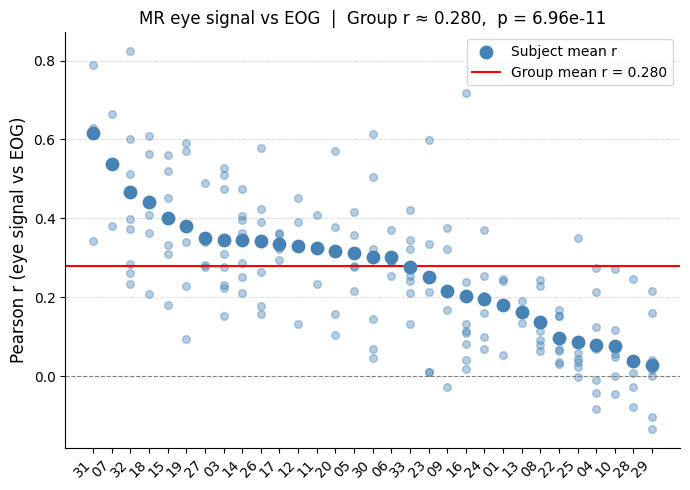

In [17]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ── 1. Collect per-run correlations ──────────────────────────────────────────

records = []

for subject, run, run_df in mrio.iter_run_events():
    eye_signal = run_df["mreyemove"]

    # eog_rows = run_df["eog"]
    eog_rows = run_df["conv_framewise_displacement"]
    if eog_rows.isna().any():
        print(f"  Skipping {subject} run {run} (no EOG data)")
        continue

    eog_signal = eog_rows.values.astype(float)

    if len(eye_signal) != len(eog_signal):
        print(f"  Skipping {subject} run {run} (length mismatch: eye={len(eye_signal)}, eog={len(eog_signal)})")
        continue

    r, _ = stats.pearsonr(eye_signal, eog_signal)  
    if np.isnan(r):
        continue

    records.append(dict(
        subject=subject,
        run=run,
        r=r,
        n=len(eye_signal),
        mean_eye=np.mean(np.abs(eye_signal)),
        mean_eog=np.mean(np.abs(eog_signal)),
    ))

run_df = pd.DataFrame(records)
print(f"\nPer-run correlations ({len(run_df)} runs):")

# ── 2. Per-subject average r (Fisher z then back) ────────────────────────────

def fisher_mean_z(r_values):
    """Return Fisher-averaged correlation in z-space."""
    return np.mean(np.arctanh(np.clip(r_values, -0.9999, 0.9999)))

subj_df = (
    run_df.groupby("subject")["r"]
    .agg(z=lambda _r: fisher_mean_z(_r.values), n_runs="count")
    .reset_index()
)
subj_df["r"] = np.tanh(subj_df["z"])  # for display only


# Group-level

z_vals = subj_df["z"].values
mean_z = z_vals.mean()

group_r = np.tanh(mean_z)

t_stat, p_val = stats.ttest_1samp(subj_df["z"].values, 0)
se_z = subj_df["z"].std(ddof=1) / np.sqrt(len(subj_df))
ci_z = mean_z + np.array([-1, 1]) * stats.t.ppf(0.975, len(subj_df)-1) * se_z
ci_r = np.tanh(ci_z)  # e.g. report group r = 0.017, 95% CI [...]

print(t_stat, ci_r)
# ── 4. Plot: per-subject mean r with individual runs ─────────────────────────

subj_plot = subj_df.sort_values("r", ascending=False).reset_index(drop=True)
p_str = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.3f}"

fig, ax = plt.subplots(figsize=(7, 5))

for i, row in subj_plot.iterrows():
    runs = run_df[run_df["subject"] == row["subject"]]["r"].values
    ax.scatter([i] * len(runs), runs, color="steelblue", alpha=0.4, s=30, zorder=2)

ax.scatter(range(len(subj_plot)), subj_plot["r"],
           color="steelblue", s=80, zorder=3, label="Subject mean r")

ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(group_r, color="red", lw=1.5, ls="-", label=f"Group mean r = {group_r:.3f}")

ax.set_xticks(range(len(subj_plot)))
ax.set_xticklabels(subj_plot["subject"].str.replace("sub-", ""), rotation=45, ha="right")
ax.set_ylabel("Pearson r (eye signal vs EOG)", fontsize=12)
ax.set_title(f"MR eye signal vs EOG  |  Group r ≈ {group_r:.3f},  p = {p_str}", fontsize=12)
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/Users/zach/2025_RA/matthias/final images/correlations/mreyemove_eog_r_per_subject.svg", dpi=300)
plt.show()

In [3]:

# --- Run searchlight and plot ---
radius_mm = 38  # geodesic radius in mm
surf_mesh = "fsaverage7"

neighborhoods = build_fsaverage_neighborhoods(surf_mesh=surf_mesh, radius_mm=radius_mm)
corr_maps = {}
window_size = 3 


[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Building geodesic neighborhoods (radius=38mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 2230, Median: 2164, Min: 799, Max: 4393
Building geodesic neighborhoods (radius=38mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 2272, Median: 2208, Min: 865, Max: 4762


In [32]:
from SleepMReye.plotting import plot_surface_searchlight
from pathlib import Path
from nilearn.image import new_img_like
from mreyemove.plotting.glm import plot_img_on_surf_with_contour, custom_cmap
from mreyemove.analysis.searchlight_correlation import run_fsaverage_surface_searchlight_correlation
from mreyemove.analysis.searchlight_correlation import build_fsaverage_neighborhoods
import nibabel as nib

threshold = 0.3
brain_mask = nib.load(mrio.second_level_glm_mask_path()).get_fdata().astype(bool)

for state_1 in ("", "_W","_S"):
    output_dir = Path("/Users/zach/2025_RA/matthias/final images/group_level/eog_mreyemove_rho_maps/thresholded")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{state_1}_correlation_map"
    data_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="clean-with-fd-clamped-original-sleep-incl-nrem3-flame")
    data_b,_ = mrio.load_FLAME_result(contrast=f"eog{state_1}", desc_add="clean-eog-sleep-nrem3-flame")    
    
    print(data_a.t_stat.shape)

    corr_maps, _ = run_fsaverage_surface_searchlight_correlation(
        data_b.t_stat, data_a.t_stat,
        surf_mesh=surf_mesh,
        neighborhoods=neighborhoods
    )

    plot_surface_searchlight(
        corr_maps,
        surf_mesh=surf_mesh,
        inflate=True,
        title=f"Searchlight r: {state_1} mreyemove vs eog ({radius_mm}mm geodesic)",
        output_file=f"{output_path}.png"
        # threshold=0.3,
    )
    

(53, 65, 43)
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 88.0%
r_valid <= -0.3: 0.2%
n valid vertices = 163819
r_valid >=  0.3: 88.0%
r_valid <= -0.3: 0.2%
median r: 0.6548517346382141
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 90.4%
r_valid <= -0.3: 0.3%
n valid vertices = 163842
r_valid >=  0.3: 90.4%
r_valid <= -0.3: 0.3%
median r: 0.6635144054889679
median r: 0.6590730547904968
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
(53, 65, 43)
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 87.5%
r_valid <= -0.3: 0.2%
n valid vertices = 163826
r_valid >=  0.3: 87.5%
r_valid <= -0.3: 0.2%
median r: 0.6713175773620605
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 93.4%
r_valid <= -0.3: 0.0%
n valid vertices = 163842
r_valid >=  0.3: 93.4%
r_valid <= -0

In [35]:

from mreyemove.analysis.glm.cli import construct_desc
import os
from SUITPy import flatmap
from mreyemove.analysis.searchlight_correlation import build_neighbourhoods, surface_searchlight_correlation
from pathlib import Path
from mreyemove.plotting.glm import custom_cmap

# config = GLMConfig.from_yaml(
#     "/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_cer.yml")
# desc_add = construct_desc(dataset=mrio, config=config)
# desc_add = f"{desc_add}-{config.second_level.method}"
# desc_add = "clean-with-fd-clamped-original-nrem3-incl-cer-cov-flame"

output_dir = Path('/Users/zach/2025_RA/matthias/final images/group_level/eog_mreyemove_rho_maps/thresholded')
output_dir.mkdir(exist_ok=True, parents=True)

state_compares = [
    # ("1", "2"),
    ("W", "1"),
    ("W", "2"),
    # ("W", "S")
    
]

radius_mm = 29.0
surf_path = os.path.join(flatmap._base_dir,'surfaces', f'PIAL_FSL.surf.gii')
neighbourhoods = build_neighbourhoods(surf_mesh=surf_path, radius_mm=radius_mm)

# for state_1, state_2 in state_compares:
print(f"\n=== Cerbellum eog vs mreyemove ===")
title = f"searchlight_surface_eog_mreyemove_{radius_mm}"

data_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove", desc_add="clean-with-fd-clamped-original-nrem3-incl-cer-cov-flame")
data_b,_ = mrio.load_FLAME_result(contrast=f"eog", desc_add="clean-with-fd-clamped-eog-sleep-cer-cov-flame")    


surf_a = flatmap.vol_to_surf(data_a.t_stat, space='FSL')
surf_b = flatmap.vol_to_surf(data_b.t_stat, space='FSL')

results = surface_searchlight_correlation(
    map_a_surf=surf_a,
    map_b_surf=surf_b,
    neighborhoods=neighbourhoods,
    min_vertices=10,
)

# corr_maps[f"{state_1}_{state_2}"] = results

# ax = flatmap.plot(data=results, cmap=custom_cmap(), 
#         new_figure=True, 
#         colorbar=True, 
#         render='matplotlib',
#         cscale=[-1.0, 1.0])
# ax.set_title(title)
# 
# output_path = output_dir / f"{title}.png"
# 
# ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")


Building geodesic neighborhoods (radius=29.0mm)...


Dijkstra neighborhoods:   0%|          | 0/58 [00:00<?, ?it/s]

Neighbors — Mean: 827, Median: 845, Min: 1, Max: 1336

=== Cerbellum eog vs mreyemove ===
n vertices = 28935
r_valid >=  0.3: 91.6%
r_valid <= -0.3: 0.9%
n valid vertices = 28834
r_valid >=  0.3: 91.9%
r_valid <= -0.3: 0.9%
median r: 0.7246828377246857


In [29]:
ratio

0.9523883489870226